# 🔎 U-Phase · Understanding the Data

Quellenwahl, Datenqualität, Exploration, räumliche Struktur und Skalierung.

**Projekt:** MietCheck · Big Data & Data Analytics · QUA³CK

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## 🗂️ Aufgabe 1: Datensätze auswählen und verstehen

### 1.1 Zensus 2022 – Trainingsbasis

Sieben amtliche Gitterprodukte werden über die `Gitter_ID_100m` verbunden: Nettokaltmiete nach Baualter/Wohnungsgröße, Bevölkerung, Haushaltsgröße, Eigentumsquote, Leerstand, Wohnfläche und Wohnungszahl. Lizenz: Datenlizenz Deutschland – Namensnennung 2.0.

### 1.2 GREIX – aktueller Markt

Der GREIX des Kiel Instituts liefert nominale quartalsweise Angebotsmieten. Er bleibt **außerhalb des Zensus-Trainingsziels**, weil beide Quellen unterschiedliche Zeitpunkte und Mietrealitäten messen.

| Quelle/Kennzahl | Wert | Einordnung |
|---|---:|---|
| Zensus-Ziel | Nettokaltmiete in €/m² | Stichtag 15.05.2022 |
| Modellzeilen | 2.058.569 | reproduzierbarer Join |
| eindeutige 100-m-Zellen | 1.184.386 | Deutschland |
| amtlich unsicheres Ziel | 11,5 % | Kennzeichnung bleibt erhalten |
| GREIX | 2.166 Beobachtungen | 2012-Q1 bis 2026-Q1 |

**Grain der Trainingsmatrix:** Eine Zeile steht für die Kombination aus einer 100-m-Gitterzelle, einer Baualtersklasse und einer Wohnungsgrößenklasse. Der aktuelle GREIX-Markt wird erst in der App auf Regionsebene ergänzt.

## 📊 Aufgabe 2: Erste Graphen und deskriptive Analyse

Für die Visualisierung wird eine deterministische Stichprobe von höchstens 200.000 Zeilen verwendet. Die ML-Pipeline trainiert später auf der vollständigen bzw. jeweils dokumentierten Datenmenge. Die folgenden Codezellen erzeugen echte Analysen; reine Beschreibungs- und Ergebnistabellen stehen direkt als Markdown im Notebook.

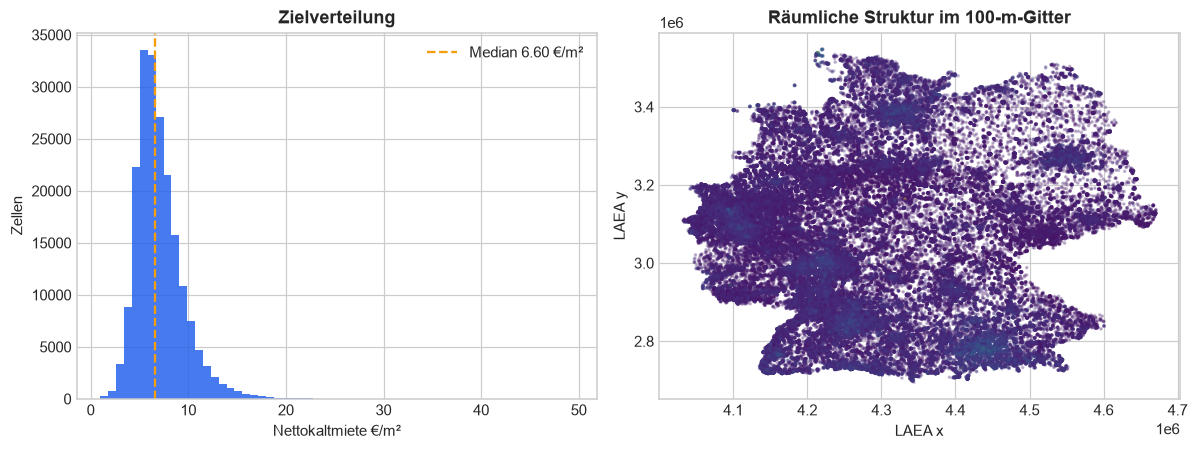

In [2]:
features = ["x_laea_m", "y_laea_m", "building_after_1990",
            "dwelling_over_65sqm", "population", "avg_household_size",
            "ownership_rate_pct", "vacancy_rate_pct", "avg_dwelling_area_sqm",
            "dwelling_count", "rent_eur_sqm", "spatial_block_25km"]
data = pd.read_parquet(ROOT / "data/processed/model_table.parquet", columns=features)
sample = data.sample(n=min(200_000, len(data)), random_state=2026)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(sample["rent_eur_sqm"], bins=60, color=COLORS["blue"], alpha=.85)
axes[0].axvline(sample["rent_eur_sqm"].median(), color=COLORS["amber"], linestyle="--",
                label=f"Median {sample['rent_eur_sqm'].median():.2f} €/m²")
axes[0].set(title="Zielverteilung", xlabel="Nettokaltmiete €/m²", ylabel="Zellen")
axes[0].legend()
axes[1].scatter(sample["x_laea_m"], sample["y_laea_m"], c=sample["rent_eur_sqm"],
                s=2, alpha=.25, cmap="viridis")
axes[1].set(title="Räumliche Struktur im 100-m-Gitter", xlabel="LAEA x", ylabel="LAEA y")
plt.tight_layout(); plt.show()

**Interpretation:** Die Zielverteilung ist rechtsschief und räumlich deutlich strukturiert. Hohe und niedrige Mieten bilden regionale Cluster statt zufälliger Einzelpunkte. Deshalb wäre ein zufälliger Zeilensplit zu optimistisch; die A- und C-Phase trennen vollständige 25-km-Raumblöcke.

## 🧹 Aufgabe 3: Fehlende Werte und Datenqualität

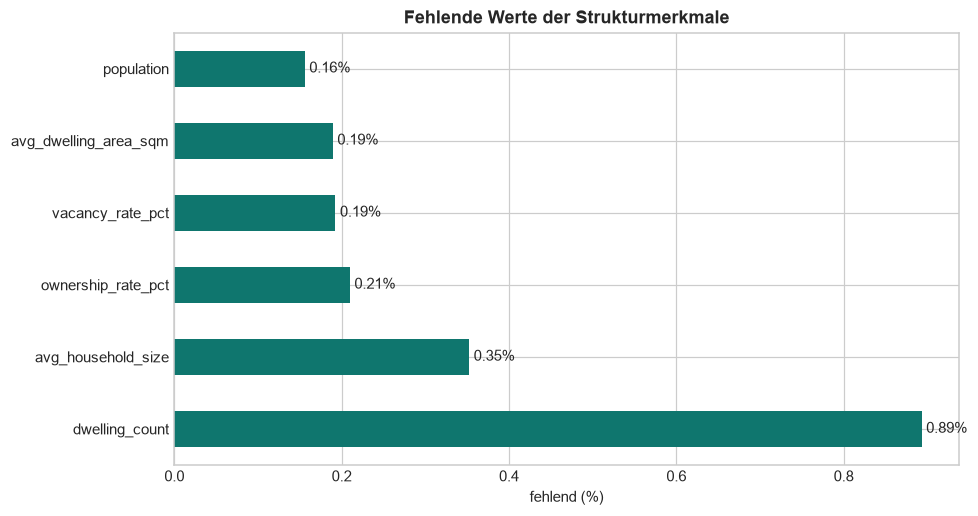

In [3]:
build = load_json("reports/dataset_build_report.json")
non_null = pd.Series(build["feature_non_null_share"]).sort_values()
missing = (1 - non_null).mul(100)
ax = missing.plot.barh(color=COLORS["teal"])
ax.set(title="Fehlende Werte der Strukturmerkmale", xlabel="fehlend (%)", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)
plt.tight_layout(); plt.show()

assert build["rows"] >= 2_000_000
assert build["unique_grid_cells"] > 1_000_000
assert non_null.min() > .98

Fehlende Strukturmerkmale werden **innerhalb jedes Trainingsfolds** per Median imputiert; Missing-Indikatoren erhalten die Information, dass ein Wert fehlte. Das Ziel wird nie imputiert. Unsicherheitskennzeichen der amtlichen Quelle bleiben als Merkmale erhalten.

## ⚖️ Aufgabe 4: Alles auf einen vergleichbaren Maßstab bringen

### 4.1 Wahl der Skalierungsmethode

`StandardScaler` transformiert jedes numerische Merkmal mit Mittelwert und Standardabweichung des jeweiligen **Trainingsfolds**:

**z = (x − μ<sub>train</sub>) / σ<sub>train</sub>**

Das ist für Ridge, LinearSVR, RBF-SVR und MLP wichtig, weil Distanz, Regularisierung oder Gradienten sonst durch große Einheiten wie LAEA-Meter dominiert würden. Entscheidungsbaum, Random Forest und HistGradientBoosting benötigen keine Skalierung, weil Schwellenaufteilungen gegenüber monotoner Skalierung invariant sind.

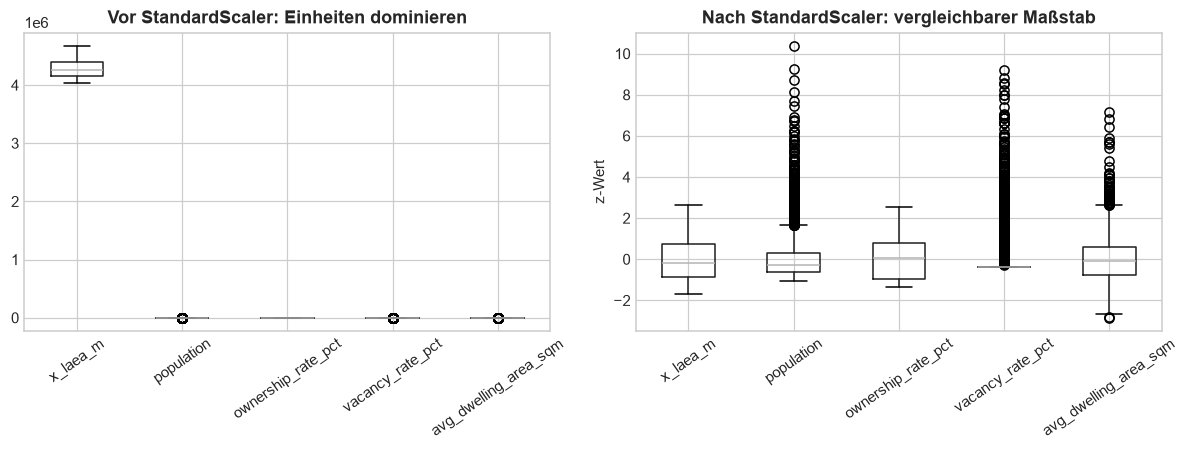

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

scale_features = ["x_laea_m", "population", "ownership_rate_pct",
                  "vacancy_rate_pct", "avg_dwelling_area_sqm"]
train_like = sample[scale_features].iloc[:150_000]
imputed = SimpleImputer(strategy="median").fit_transform(train_like)
scaler = StandardScaler().fit(imputed)
scaled = pd.DataFrame(scaler.transform(imputed), columns=scale_features)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
before = train_like.sample(5_000, random_state=2026)
after = scaled.sample(5_000, random_state=2026)
before.boxplot(ax=axes[0], rot=35)
after.boxplot(ax=axes[1], rot=35)
axes[0].set_title("Vor StandardScaler: Einheiten dominieren")
axes[1].set_title("Nach StandardScaler: vergleichbarer Maßstab")
axes[1].set_ylabel("z-Wert")
plt.tight_layout(); plt.show()

### 4.2 Ergebnis und Auswirkungen auf die Algorithmen

| Modellfamilie | StandardScaler? | Fachlicher Grund |
|---|---:|---|
| Ridge | ja | Regularisierung hängt von der Merkmalsgröße ab |
| LinearSVR / RBF-SVR | ja | Abstände und Margin müssen vergleichbar sein |
| MLP | ja | stabilere Gradientenoptimierung |
| Decision Tree / Random Forest / HGB | nein | Schwellenaufteilungen sind skaleninvariant |

Die Skalierung steckt als Pipeline-Schritt in jedem CV-Fold und wird niemals vor dem Split auf den Gesamtdaten gefittet. So entsteht kein Leakage. Für den später ausgewählten HGB-Champion wird bewusst **kein** Scaler gespeichert, weil er fachlich unnötig wäre; der Skalierungsnachweis gehört zur fairen Auswahl der skalenempfindlichen Kandidaten.

## ✅ Aufgabe 5: Zusammenfassung und Interpretation

- 2.058.569 Zeilen und 1.184.386 Gitterzellen erfüllen den Big-Data-Anspruch.
- Ziel und Merkmale zeigen starke räumliche Struktur; Random Split wäre zu optimistisch.
- Datenlücken sind gering, werden aber fold-intern behandelt und dokumentiert.
- Zensus und GREIX bleiben wegen unterschiedlicher Messkonzepte getrennt.
- StandardScaler ist für SVM/Ridge/MLP notwendig, für baumbasierte Verfahren nicht.

---

**Reproduzierbarkeit:** Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die genannten Skripte erzeugen sie aus den öffentlichen Rohdaten erneut. Schwere Trainingsläufe liegen bewusst in getesteten Skripten, damit Notebook und produktive Pipeline dieselben Splits, Parameter und Reports verwenden.